# Datenaufbereitung für Prophet — PM2.5 Beijing

**Capstone-Projekt · CRISP-DM Phase 3 (Data Preparation)**  
Bettina Gertjerenken · Kai Steffen

Dieses Notebook bereitet die Rohdaten **speziell für Facebook Prophet** auf:

1. eine Station laden (später leicht auf alle 12 erweiterbar),
2. auf ein lückenloses Stundenraster bringen,
3. fehlende Werte auffüllen (Imputation),
4. **Windrichtung `wd` kodieren** (zyklisch als sin/cos),
5. in das von Prophet erwartete Format `ds` / `y` bringen,
6. den **gesamten Zeitraum** für den Export aufbereiten (kein Train/Test-Split),
7. mit Sanity-Checks absichern und speichern.

> **Prophet-Format:** Prophet braucht immer genau zwei Pflichtspalten: `ds` (Zeitstempel) und `y` (Zielwert = PM2.5). 
Zusätzliche **numerische** Spalten dürfen als Regressoren dienen.

## 1. Bibliotheken & eine Station laden

Prophet ist **univariat** (eine Zeitreihe pro Modell). Wir starten mit einer repräsentativen Station. 
Über `STATION` wählt ihr jede andere oder loopt später über alle 12.

In [1]:
import glob, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/PRSA_Data_20130301-20170228")
if not DATA_DIR.exists():
    DATA_DIR = Path("capstone projekt/data/PRSA_Data_20130301-20170228")

STATION = "Aotizhongxin"                       # <-- spaeter andere Station / Schleife
NUM_REGS = ["PM10","SO2","NO2","CO","O3","TEMP", "DEWP", "PRES", "WSPM", "RAIN"]   # numerische Wetter-Regressoren
#"No","year","month","day","hour","PM2.5","TEMP","PRES","DEWP","RAIN","wd","WSPM","station"
df = pd.read_csv(DATA_DIR / f"PRSA_Data_{STATION}_20130301-20170228.csv")
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

# PM2.5 + numerische Regressoren + Windrichtung (kategorial) laden
s = (df[["datetime", "PM2.5"] + NUM_REGS + ["wd"]]
       .sort_values("datetime")
       .set_index("datetime"))

print(f"Station: {STATION}")
print(f"Zeilen: {len(df)}")
print(f"Zeitraum: {s.index.min()} bis {s.index.max()}")

Station: Aotizhongxin
Zeilen: 35064
Zeitraum: 2013-03-01 00:00:00 bis 2017-02-28 23:00:00


In [2]:
# 1. Erstelle einen vollständigen Zeitindex
full_range = pd.date_range(start=s.index.min(), end=s.index.max(), freq='H')

# 2. Reindexierung: Fehlende Stunden werden nun als NaN eingefügt
s_reindexed = s.reindex(full_range)

target_columns = ["PM2.5"] + NUM_REGS

def find_gaps(series, threshold=3):
    # Identifiziere alle NaNs (echte fehlende Werte + durch Reindexierung entstandene Lücken)
    is_nan = series.isna()
    
    # Gruppierung: Jedes Mal, wenn sich der Zustand von (NaN -> Wert) ändert, 
    # wird eine neue ID vergeben.
    groups = (is_nan != is_nan.shift()).cumsum()
    
    # Zähle die Länge jeder Gruppe
    gap_lengths = is_nan.groupby(groups).sum()
    
    # Filtere nur die Gruppen, die tatsächlich NaNs sind
    nan_gaps = gap_lengths[is_nan.groupby(groups).first() == True]
    
    # Gib die Längen zurück, die über dem Schwellenwert liegen
    return nan_gaps[nan_gaps > threshold]

# 3. Überprüfung durchführen
print(f"Station: {STATION}")
for col in target_columns:
    gaps = find_gaps(s_reindexed[col])
    if not gaps.empty:
        print(f" - Spalte '{col}': {len(gaps)} Lücke(n) gefunden (max. Länge: {int(gaps.max())}h)")
    else:
        print(f" - Spalte '{col}': Keine Lücken > 3h")

Station: Aotizhongxin
 - Spalte 'PM2.5': 23 Lücke(n) gefunden (max. Länge: 343h)
 - Spalte 'PM10': 16 Lücke(n) gefunden (max. Länge: 343h)
 - Spalte 'SO2': 22 Lücke(n) gefunden (max. Länge: 343h)
 - Spalte 'NO2': 23 Lücke(n) gefunden (max. Länge: 343h)
 - Spalte 'CO': 60 Lücke(n) gefunden (max. Länge: 343h)
 - Spalte 'O3': 57 Lücke(n) gefunden (max. Länge: 343h)
 - Spalte 'TEMP': 2 Lücke(n) gefunden (max. Länge: 6h)
 - Spalte 'DEWP': 2 Lücke(n) gefunden (max. Länge: 6h)
 - Spalte 'PRES': 2 Lücke(n) gefunden (max. Länge: 6h)
 - Spalte 'WSPM': 2 Lücke(n) gefunden (max. Länge: 5h)
 - Spalte 'RAIN': 2 Lücke(n) gefunden (max. Länge: 6h)


C:\Users\betti\AppData\Local\Temp\ipykernel_2744\96436916.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=s.index.min(), end=s.index.max(), freq='H')


## 2. Lückenloses Stundenraster herstellen

Ein **regelmäßiges Zeitraster** macht Split und Imputation sauberer. Wir legen einen durchgehenden 
Stundenindex an (`reindex`); fehlende Stunden werden dadurch explizit zu `NaN`.

In [3]:
voll = pd.date_range(s.index.min(), s.index.max(), freq="h")
s = s.reindex(voll)
print(f"Stunden im Raster: {len(s)}")

Stunden im Raster: 35064


## 3. Fehlende Werte auffüllen (Imputation)

Zuerst zählen, **wie viel fehlt**:

In [4]:
s.isna().sum()

PM2.5     925
PM10      718
SO2       935
NO2      1023
CO       1776
O3       1719
TEMP       20
DEWP       20
PRES       20
WSPM       14
RAIN       20
wd         81
dtype: int64

Die **numerischen** Spalten füllen wir mit **zeitlicher Interpolation** (`method="time"`): fehlende Werte 
werden linear zwischen den benachbarten echten Messwerten geschätzt, gewichtet nach zeitlichem Abstand. 
`limit_direction="both"` füllt auch Ränder.

> ⚠️ Die kategoriale Spalte `wd` kann man **nicht** interpolieren — die behandeln wir gleich separat (Abschnitt 4).

> ⚠️ Bei sehr langen Lücken ist lineare Interpolation nur eine Näherung. Für die finale Modellierung ggf. `limit=...` setzen.

In [5]:
s_imp = s.copy()
s_imp[["PM2.5"] + NUM_REGS] = s[["PM2.5"] + NUM_REGS].interpolate(
    method="time", limit_direction="both")
print("Fehlende Werte NACH Imputation (numerisch):")
print(s_imp[["PM2.5"] + NUM_REGS].isna().sum())

Fehlende Werte NACH Imputation (numerisch):
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
DEWP     0
PRES     0
WSPM     0
RAIN     0
dtype: int64


Wo Lücken lagen (rote Balken = PM2.5 fehlte):

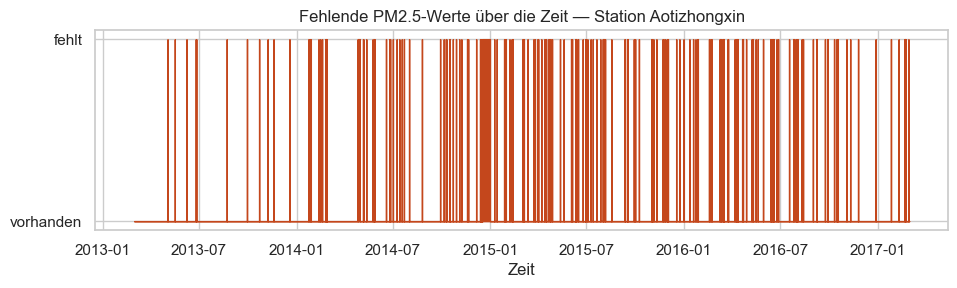

In [6]:
plt.figure(figsize=(11, 2.6))
luecke = s["PM2.5"].isna().astype(int)
plt.fill_between(s.index, luecke, step="mid", color="#C4471C")
plt.yticks([0, 1], ["vorhanden", "fehlt"])
plt.title(f"Fehlende PM2.5-Werte über die Zeit — Station {STATION}")
plt.xlabel("Zeit"); plt.show()

Eine aufgefüllte Lücke konkret (orange = interpoliert):

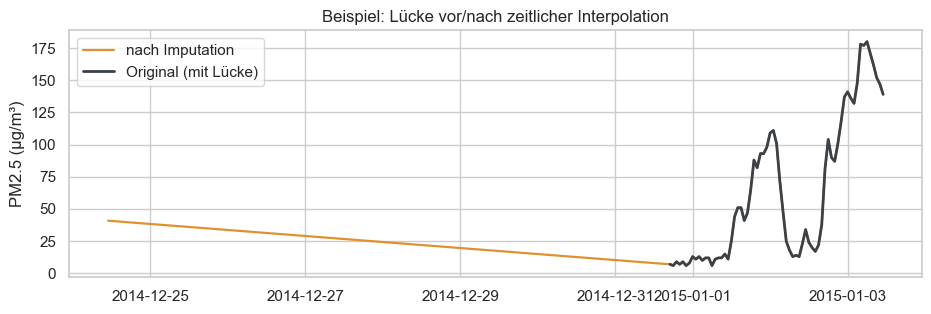

In [7]:
na_idx = s.index[s["PM2.5"].isna()]
mitte = na_idx[len(na_idx)//2]
w = pd.Timedelta(days=5)
seg  = s.loc[mitte-w:mitte+w, "PM2.5"]
segi = s_imp.loc[mitte-w:mitte+w, "PM2.5"]
plt.figure(figsize=(11, 3.2))
plt.plot(segi.index, segi.values, color="#E0912F", lw=1.6, label="nach Imputation")
plt.plot(seg.index, seg.values, color="#3A4148", lw=2.0, label="Original (mit Lücke)")
plt.title("Beispiel: Lücke vor/nach zeitlicher Interpolation")
plt.ylabel("PM2.5 (µg/m³)"); plt.legend(); plt.show()

## 4. Windrichtung `wd` kodieren (zyklisch)

Prophet-Regressoren müssen **numerisch** sein — `wd` ist aber Text (`N`, `NNE`, …). 
Eine Windrichtung ist zudem **zyklisch**: `NNW` (337.5°) und `N` (0°) liegen dicht beieinander, obwohl die Zahlen weit auseinander sind. 
Deshalb kodieren wir sie in **zwei** Spalten mit Sinus und Kosinus des Winkels — so bleibt die Nachbarschaft erhalten.

Fehlende `wd`-Werte füllen wir vorher per `ffill`/`bfill` (nächster gültiger Nachbar).

> Alternative: 16 Dummy-Spalten per One-Hot (`pd.get_dummies`). Die sin/cos-Variante ist kompakter (nur 2 Spalten) und spiegelt die Kreisform wider.

In [8]:
# 1) Lücken der Kategorie fuellen
s_imp["wd"] = s_imp["wd"].ffill().bfill()

# 2) 16 Kompassrichtungen -> Grad
kompass = {"N":0, "NNE":22.5, "NE":45, "ENE":67.5, "E":90, "ESE":112.5,
           "SE":135, "SSE":157.5, "S":180, "SSW":202.5, "SW":225, "WSW":247.5,
           "W":270, "WNW":292.5, "NW":315, "NNW":337.5}
grad = s_imp["wd"].map(kompass)

# 3) zyklische sin/cos-Kodierung
s_imp["wd_sin"] = np.sin(np.deg2rad(grad))
s_imp["wd_cos"] = np.cos(np.deg2rad(grad))

# vollstaendige Regressor-Liste fuer Prophet (add_regressor)
REGRESSOREN = NUM_REGS + ["wd_sin", "wd_cos"]
print(REGRESSOREN)
print()
print(s_imp[["wd", "wd_sin", "wd_cos"]].head())

['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'wd_sin', 'wd_cos']

                      wd    wd_sin    wd_cos
2013-03-01 00:00:00  NNW -0.382683  0.923880
2013-03-01 01:00:00    N  0.000000  1.000000
2013-03-01 02:00:00  NNW -0.382683  0.923880
2013-03-01 03:00:00   NW -0.707107  0.707107
2013-03-01 04:00:00    N  0.000000  1.000000


Zur Veranschaulichung: die 16 Richtungen liegen als `(wd_sin, wd_cos)` schön auf dem Einheitskreis — 
benachbarte Himmelsrichtungen sind auch im Zahlenraum benachbart.

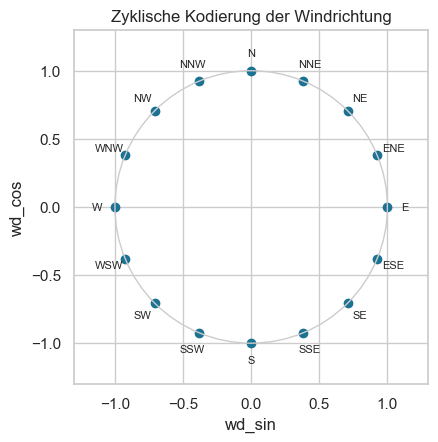

In [9]:
plt.figure(figsize=(4.6, 4.6))
for k, d in kompass.items():
    x, y = np.sin(np.deg2rad(d)), np.cos(np.deg2rad(d))
    plt.scatter(x, y, color="#1C7293")
    plt.text(x*1.13, y*1.13, k, ha="center", va="center", fontsize=8)
plt.gca().add_artist(plt.Circle((0, 0), 1, fill=False, color="#CCC"))
plt.xlim(-1.3, 1.3); plt.ylim(-1.3, 1.3); plt.gca().set_aspect("equal")
plt.xlabel("wd_sin"); plt.ylabel("wd_cos")
plt.title("Zyklische Kodierung der Windrichtung"); plt.show()

## 5. In das Prophet-Format `ds` / `y` bringen

`PM2.5` → `y`, der Zeitindex wird zur Spalte `ds`. Die Regressor-Spalten bleiben erhalten — 
für **univariates** Prophet nutzt ihr nur `ds`+`y`, für **Regressoren** zusätzlich die übrigen Spalten.

In [10]:
prophet_df = (s_imp[["PM2.5"] + REGRESSOREN]
                .rename(columns={"PM2.5": "y"})
                .reset_index())
prophet_df = prophet_df.rename(columns={prophet_df.columns[0]: "ds"})
prophet_df.head()

,ds,y,PM10,SO2,NO2,CO,O3,TEMP,DEWP,PRES,WSPM,RAIN,wd_sin,wd_cos
0,2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,-18.8,1023.0,4.4,0.0,-0.382683,0.923880
1,2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,-18.2,1023.2,4.7,0.0,0.000000,1.000000
2,2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,-18.2,1023.5,5.6,0.0,-0.382683,0.923880
3,2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,-19.4,1024.5,3.1,0.0,-0.707107,0.707107
4,2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,-19.5,1025.2,2.0,0.0,0.000000,1.000000


## 6. Export-Zeitraum

Die Daten laufen vom **01.03.2013** bis **28.02.2017**. Es gibt **keinen Train/Test-Split** — 
wir geben den **gesamten Zeitraum** als eine durchgehende Zeitreihe aus. Ein Split (falls gewünscht) 
kann später im Modellierungs-Notebook je nach Chronos-Workflow (Zero-/Few-Shot vs. Fine-Tuning) erfolgen.

In [11]:
print(f"Zeitraum: {prophet_df['ds'].min()}  bis  {prophet_df['ds'].max()}  ->  {len(prophet_df)} Zeilen")
print("Kein Train/Test-Split — der gesamte Zeitraum wird exportiert.")

Zeitraum: 2013-03-01 00:00:00  bis  2017-02-28 23:00:00  ->  35064 Zeilen
Kein Train/Test-Split — der gesamte Zeitraum wird exportiert.


Verlauf über den gesamten Zeitraum:

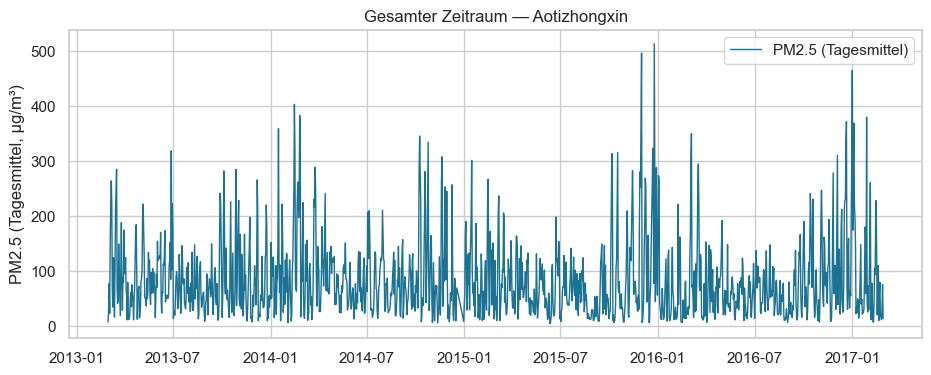

In [12]:
plt.figure(figsize=(11, 4))
tg = prophet_df.set_index("ds")["y"].resample("D").mean()   # Tagesmittel nur zur Anzeige
plt.plot(tg.index, tg.values, color="#1C7293", lw=1.0, label="PM2.5 (Tagesmittel)")
plt.ylabel("PM2.5 (Tagesmittel, µg/m³)")
plt.title(f"Gesamter Zeitraum — {STATION}")
plt.legend(loc="upper right"); plt.show()

Plausibilitätscheck — Verteilung PM2.5 über den gesamten Zeitraum:

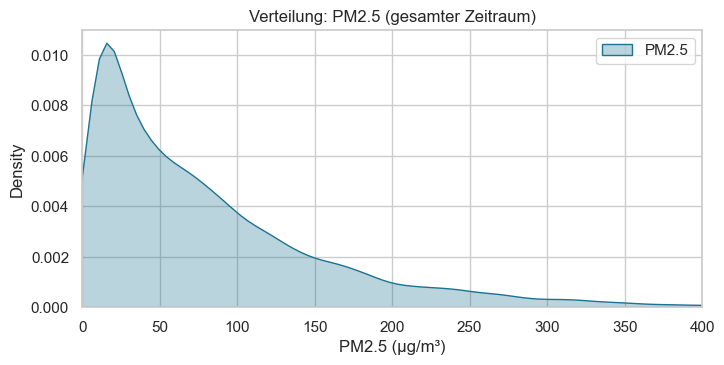

In [13]:
plt.figure(figsize=(8, 3.6))
sns.kdeplot(prophet_df["y"], color="#1C7293", fill=True, alpha=.3, label="PM2.5")
plt.xlim(0, 400); plt.xlabel("PM2.5 (µg/m³)")
plt.title("Verteilung: PM2.5 (gesamter Zeitraum)"); plt.legend(); plt.show()

## 7. Sanity-Checks

Vor dem Speichern prüfen wir, dass alles sauber ist — inkl. **keine NaN in den Regressoren**:

In [14]:
print("Sanity-Checks:")
print(f"  y hat NaN?  {prophet_df['y'].isna().any()}")
print(f"  Regressoren NaN?  {prophet_df[REGRESSOREN].isna().any().any()}")
print(f"  ds sortiert & eindeutig? {prophet_df['ds'].is_monotonic_increasing and prophet_df['ds'].is_unique}")
print(f"  Spalten: {list(prophet_df.columns)}")

Sanity-Checks:
  y hat NaN?  False
  Regressoren NaN?  False
  ds sortiert & eindeutig? True
  Spalten: ['ds', 'y', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'wd_sin', 'wd_cos']


## 8. Speichern für die Modellierung (Phase 4)

In [15]:
out = Path("../data/prepared_chronos/basis")
out.mkdir(parents=True, exist_ok=True)
prophet_df.to_csv(out / f"chronos_{STATION}.csv", index=False)
print("gespeichert:")
print("  ", out / f"chronos_{STATION}.csv", f"({len(prophet_df)} Zeilen)")

gespeichert:
   ..\data\prepared_chronos\basis\chronos_Aotizhongxin.csv (35064 Zeilen)


## 9. Alle 12 Stationen in einer Schleife

Bisher haben wir **eine** Station aufbereitet. Jetzt packen wir die exakt gleichen Schritte (Raster → Imputation → Windrichtung kodieren → `ds`/`y`) in eine **Funktion** und lassen sie über **alle 12 Stationen** laufen. Je Station entsteht eine eigene `chronos_<Station>.csv` mit dem **gesamten Zeitraum** (kein Train/Test-Split).

> So sind am Ende **alle Zeitreihen modellfertig** — nicht nur die Beispielstation.

In [16]:
def station_aufbereiten(station):
    """Rohdaten einer Station -> (gesamter Zeitraum als DataFrame, pm25_luecken_prozent). Gleiche Schritte wie oben."""
    d = pd.read_csv(DATA_DIR / f"PRSA_Data_{station}_20130301-20170228.csv")
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]])
    ss = (d[["datetime", "PM2.5"] + NUM_REGS + ["wd"]]
            .sort_values("datetime").set_index("datetime"))
    ss = ss.reindex(pd.date_range(ss.index.min(), ss.index.max(), freq="h"))

    pm25_luecken = ss["PM2.5"].isna().mean() * 100          # vor Imputation (zur Kontrolle)

    # Imputation (numerisch) + Windrichtung fuellen & zyklisch kodieren
    ss[["PM2.5"] + NUM_REGS] = ss[["PM2.5"] + NUM_REGS].interpolate(method="time", limit_direction="both")
    ss["wd"] = ss["wd"].ffill().bfill()
    grad = ss["wd"].map(kompass)
    ss["wd_sin"] = np.sin(np.deg2rad(grad))
    ss["wd_cos"] = np.cos(np.deg2rad(grad))

    # Prophet-Format, gesamter Zeitraum (kein Split)
    pdf = ss[["PM2.5"] + REGRESSOREN].rename(columns={"PM2.5": "y"}).reset_index()
    pdf = pdf.rename(columns={pdf.columns[0]: "ds"})
    return pdf, pm25_luecken

# alle Stationsnamen automatisch aus den Dateinamen holen
stationen = [pp.name.replace("PRSA_Data_", "").replace("_20130301-20170228.csv", "")
             for pp in sorted(DATA_DIR.glob("*.csv"))]

out = Path("../data/prepared_chronos/basis"); out.mkdir(parents=True, exist_ok=True)
zusammenfassung = []
for st in stationen:
    pdf, gap = station_aufbereiten(st)
    pdf.to_csv(out / f"chronos_{st}.csv", index=False)
    zusammenfassung.append({"Station": st, "PM2.5-Lücken %": round(gap, 1),
                            "Zeilen": len(pdf),
                            "y NaN": bool(pdf['y'].isna().any())})

summary = pd.DataFrame(zusammenfassung)
print(summary.to_string(index=False))
print(f"\nAlle {len(stationen)} Stationen aufbereitet & gespeichert. "
      f"Zeilen gesamt: {summary['Zeilen'].sum()}")

      Station  PM2.5-Lücken %  Zeilen  y NaN
 Aotizhongxin             2.6   35064  False
    Changping             2.2   35064  False
     Dingling             2.2   35064  False
       Dongsi             2.1   35064  False
     Guanyuan             1.8   35064  False
      Gucheng             1.8   35064  False
      Huairou             2.7   35064  False
 Nongzhanguan             1.8   35064  False
       Shunyi             2.6   35064  False
      Tiantan             1.9   35064  False
       Wanliu             1.1   35064  False
Wanshouxigong             2.0   35064  False

Alle 12 Stationen aufbereitet & gespeichert. Zeilen gesamt: 420768


## 10. Optionale Behandlung: Ausreißer (Vergleich)

Die bisherige Aufbereitung (Abschnitte 1–9) ist die **Basis-Variante**. Hier erzeugen wir zusätzlich eine 
**behandelte Variante** und speichern **beide getrennt**, damit ihr sie später vergleichen könnt:

- **Ausreißer:** Kappen (`clip`) auf das **99,9-Perzentil des gesamten Zeitraums** — extreme Werte Richtung 999 werden gedeckelt.

Alles andere (Imputation, Windrichtung, Format) bleibt identisch zur Basis-Variante — der einzige Unterschied 
ist die Ausreißer-Kappung. (Eine Log-Transformation `y_log` könnt ihr bei Bedarf selbst ergänzen.)

> **Wir behandeln nur die Zielgröße PM2.5** so; die Wetter-Regressoren lassen wir wie in der Basis.

**Verzeichnisse:**  `../data/prepared_chronos/basis/`  (unbehandelt)  vs.  `../data/prepared_chronos/behandelt/`  (behandelt).

In [17]:
OUT_CAP_PCT = 99.9        # Perzentil (gesamter Zeitraum) fürs Ausreißer-Kappen

def station_behandelt(station):
    """Behandelte Variante: nur Ausreißer-Cap, sonst identisch zur Basis-Variante."""
    d = pd.read_csv(DATA_DIR / f"PRSA_Data_{station}_20130301-20170228.csv")
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]])
    ss = (d[["datetime", "PM2.5"] + NUM_REGS + ["wd"]]
            .sort_values("datetime").set_index("datetime"))
    ss = ss.reindex(pd.date_range(ss.index.min(), ss.index.max(), freq="h"))

    # Ausreisser-Cap ueber den GESAMTEN Zeitraum bestimmen und anwenden
    cap = np.nanpercentile(ss["PM2.5"], OUT_CAP_PCT)
    n_out = int((ss["PM2.5"] > cap).sum())
    ss["PM2.5"] = ss["PM2.5"].clip(upper=cap)

    # Imputation (numerisch, komplett) + Windrichtung fuellen & zyklisch kodieren -- wie in der Basis
    ss[["PM2.5"] + NUM_REGS] = ss[["PM2.5"] + NUM_REGS].interpolate(method="time", limit_direction="both")
    ss["wd"] = ss["wd"].ffill().bfill()
    grad = ss["wd"].map(kompass)
    ss["wd_sin"] = np.sin(np.deg2rad(grad)); ss["wd_cos"] = np.cos(np.deg2rad(grad))

    pdf = ss[["PM2.5"] + REGRESSOREN].rename(columns={"PM2.5": "y"}).reset_index()
    pdf = pdf.rename(columns={pdf.columns[0]: "ds"})
    return pdf, cap, n_out

# Vergleich fuer die Beispielstation
basis_df, _ = station_aufbereiten(STATION)
beh_df, cap, n_out = station_behandelt(STATION)
print(f"VERGLEICH Station {STATION}:")
print(f"  Cap (p{OUT_CAP_PCT}, gesamter Zeitraum): {cap:.0f} µg/m³")
print(f"  Ausreißer > Cap gekappt:      {n_out}")
print(f"  Zeilen Basis:                 {len(basis_df)}")
print(f"  Zeilen behandelt:             {len(beh_df)}")

VERGLEICH Station Aotizhongxin:
  Cap (p99.9, gesamter Zeitraum): 568 µg/m³
  Ausreißer > Cap gekappt:      35
  Zeilen Basis:                 35064
  Zeilen behandelt:             35064


Verteilung nach der Ausreißer-Kappung — die Cap-Linie markiert das 99,9-Perzentil:

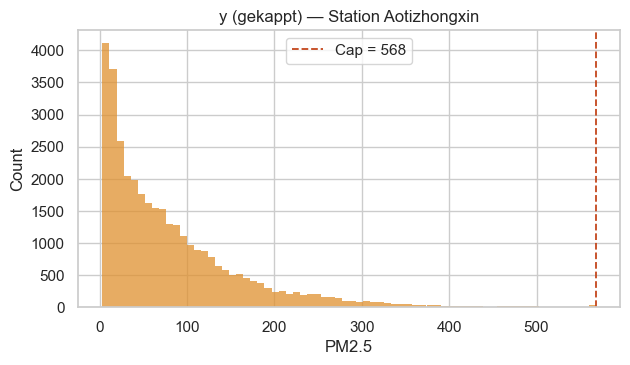

In [18]:
plt.figure(figsize=(7, 3.6))
sns.histplot(beh_df["y"], bins=70, color="#E0912F", edgecolor="none")
plt.axvline(cap, color="#C4471C", ls="--", lw=1.3, label=f"Cap = {cap:.0f}")
plt.title(f"y (gekappt) — Station {STATION}")
plt.xlabel("PM2.5"); plt.legend(); plt.show()

**Alle 12 Stationen behandelt speichern** (nach `../data/prepared_chronos/behandelt/`):

In [19]:
out_beh = Path("../data/prepared_chronos/behandelt"); out_beh.mkdir(parents=True, exist_ok=True)
rows = []
for st in stationen:
    pdf, cap, n_out = station_behandelt(st)
    pdf.to_csv(out_beh / f"chronos_{st}.csv", index=False)
    rows.append({"Station": st, "Cap p99.9": round(cap, 0), "Ausreißer gekappt": n_out, "Zeilen": len(pdf)})
summary_beh = pd.DataFrame(rows)
print(summary_beh.to_string(index=False))
print(f"\nAlle {len(stationen)} Stationen 'behandelt' gespeichert. "
      f"Zeilen gesamt: {summary_beh['Zeilen'].sum()}")

      Station  Cap p99.9  Ausreißer gekappt  Zeilen
 Aotizhongxin      568.0                 35   35064
    Changping      473.0                 35   35064
     Dingling      467.0                 35   35064
       Dongsi      625.0                 35   35064
     Guanyuan      569.0                 35   35064
      Gucheng      591.0                 35   35064
      Huairou      492.0                 35   35064
 Nongzhanguan      584.0                 34   35064
       Shunyi      565.0                 35   35064
      Tiantan      551.0                 35   35064
       Wanliu      538.0                 35   35064
Wanshouxigong      615.0                 35   35064

Alle 12 Stationen 'behandelt' gespeichert. Zeilen gesamt: 420768


### Basis oder behandelt — was nehmen?

Beide Varianten liegen jetzt vor und lassen sich im Modellierungs-Kapitel **gegeneinander testen**:

| | Basis (`prepared_chronos/basis/`) | Behandelt (`prepared_chronos/behandelt/`) |
|---|---|---|
| Ausreißer | enthalten (bis 999) | auf p99.9 gekappt |
| Zeilen | 35.064 | 35.064 (gleich viele, nur gekappte Werte) |

Empfehlung fürs Tutorial: **beide durch Chronos schicken** und über MAE/RMSE vergleichen, ob die Behandlung wirklich hilft — 
das ist ein schönes, ehrliches Ergebnis für die Präsentation. Die Entscheidung fällt damit datenbasiert im **nächsten Kapitel (Modellierung)**.

## 11. Ergebnis & Ausblick

**Ergebnis dieses Kapitels (Phase 3 – Datenaufbereitung):** Aus den Rohdaten ist ein sauberer, lückenloser Prophet-Datensatz im Format `ds` / `y` (plus kodierte Regressoren) entstanden — der **gesamte Zeitraum** (kein Train/Test-Split) — gespeichert als CSV und bereit zur Weiterverwendung.

Damit ist die Datenaufbereitung abgeschlossen. Die eigentliche **Modellierung mit Chronos** (Fit/Forecast, Metriken wie MAE/RMSE) folgt im **nächsten Kapitel (CRISP-DM Phase 4 – Modellierung)** und wird hier bewusst noch nicht gemacht. Ein etwaiger Train/Test-Split kann dort je nach Chronos-Workflow vorgenommen werden.

**Erweiterung auf alle 12 Stationen:** Die Schritte 1–8 lassen sich später einfach in eine Schleife über die Stationsnamen packen — je Station eine eigene `chronos_<Station>.csv`.